# Authors: Abdou Diaw (diawa@ornl.gov)

# ST40: Li powder dropper — axisymmetric, SOLPS background

Li grains fall from a top dropper, evaporate to Li vapor, ionise up to Li³⁺
and follow field lines (cf. Afonin *NF* **63** 126057 for the powder-dropper
modelling approach). Background: SOLPS-ITER run 13589 converted to
`input/plasma_st40_solps.h5`. Axi convention: `x = Z`, `y = R` (axis at y=0);
surf files and dumps are in (Z, R).


In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from __future__ import annotations
import math, shlex, subprocess, sys, os
from pathlib import Path
import numpy as np

import importlib
import build_geometry, plot_lpd
build_geometry = importlib.reload(build_geometry)   # pick up edits even in a
plot_lpd       = importlib.reload(plot_lpd)         # long-running kernel

ROOT          = Path.cwd().resolve()
INP           = ROOT / "input"
OPENEDGE_BIN  = Path("/Users/42d/build_oe/src/spa_mac_mpi")
OPENEDGE_ROOT = Path("/Users/42d/OpenEdge")
SOLPS_RUN     = Path("/Users/42d/Downloads/13589/run_dir")
SOLPS_GMTRY   = Path("/Users/42d/Downloads/13589/baserun/b2fgmtry")
GFILE         = Path("/Users/42d/Downloads/13589/baserun/ST40_13589_EFIT_BEST_176p80ms.geqdsk")
INP.mkdir(exist_ok=True)

def run_cmd(cmd, cwd=None, env=None):
    print("+", " ".join(shlex.quote(str(p)) for p in cmd))
    subprocess.run([str(c) for c in cmd], cwd=cwd, check=True, env=env)


## 0. Sanity check: SOLPS plasma vs OpenEdge geometry

SOLPS $T_e$ on its native EIRENE mesh, with the OpenEdge wall, the core-absorb
surface (= the mesh's inner boundary) and the separatrix of the equilibrium
embedded in `plasma_st40_solps.h5`.
The mesh was built from EFIT `ST40_13589_EFIT_BEST_176p80ms` (t = 176.8 ms,
shipped in `baserun/`), so that same g-file must be used for B and psi —
**not** the 120 ms files in `gfiles/`, whose separatrix does not match the mesh.

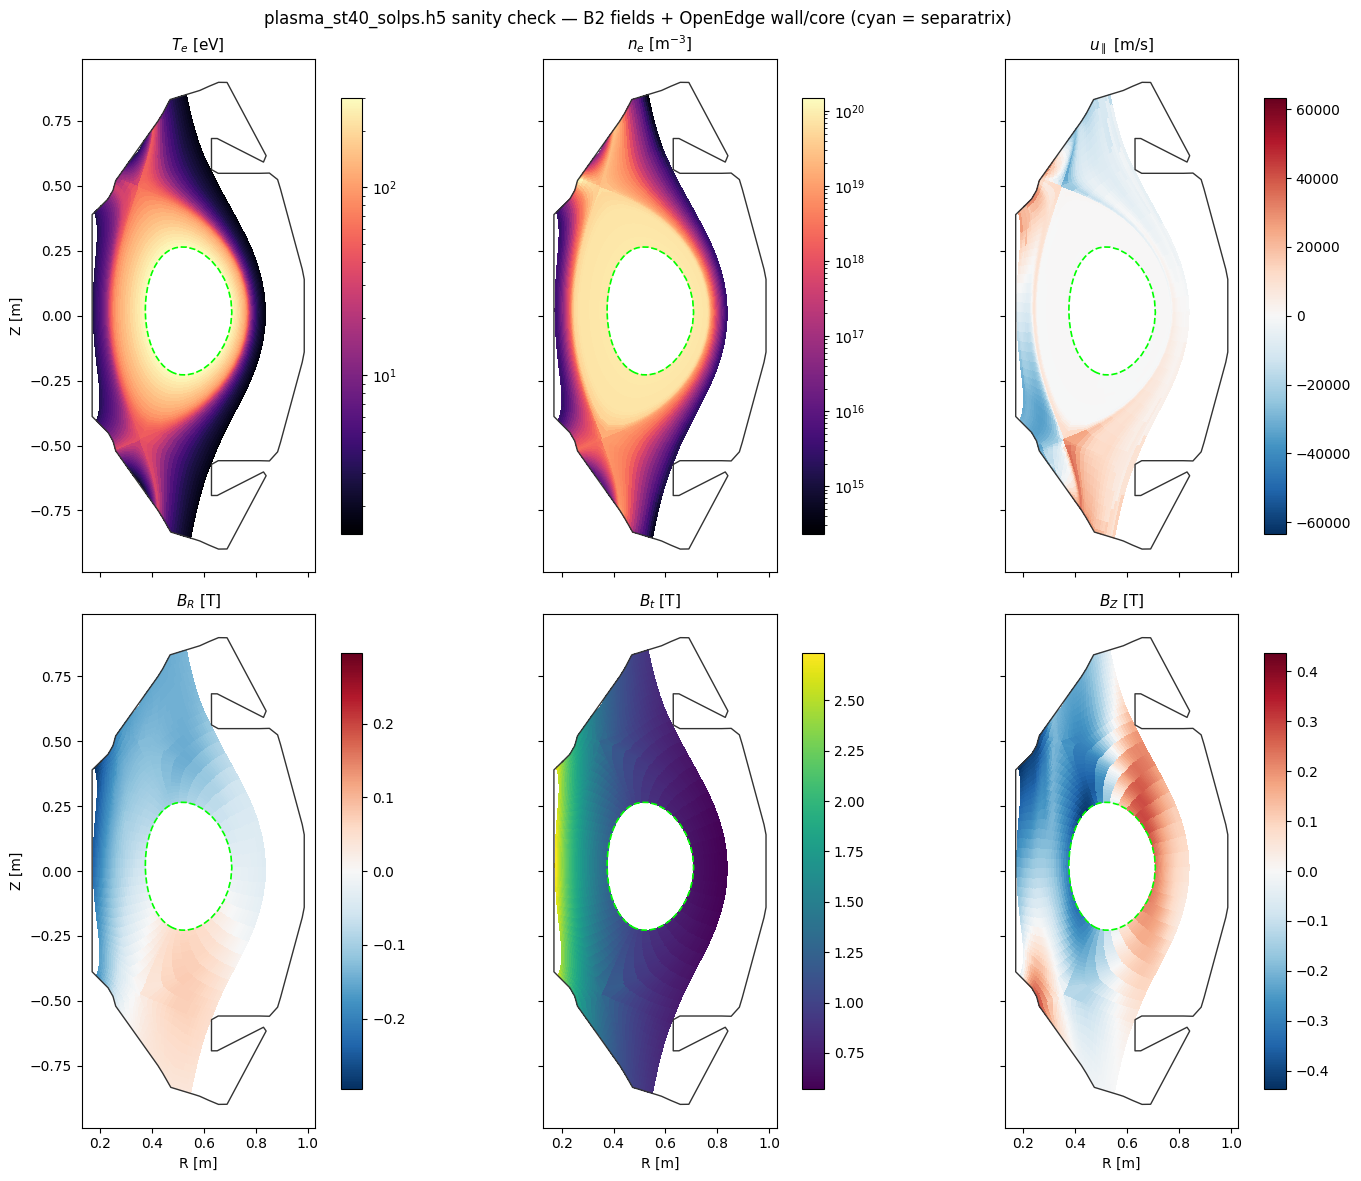

In [3]:
import h5py
from matplotlib import pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, TwoSlopeNorm

%matplotlib inline

def surf_loop_rz(path):
    pts = {}; mode = None
    for s in Path(path).read_text().splitlines():
        s = s.strip()
        if s.lower() == "points": mode = "p"; continue
        if s.lower() == "lines": mode = None; continue
        if mode == "p" and s and s[0].isdigit():
            a = s.split(); pts[int(a[0])] = (float(a[2]), float(a[1]))  # (R, Z)
    xy = [pts[i] for i in sorted(pts)] + [pts[1]]
    return np.array(xy)

with h5py.File(INP/"plasma_st40_solps.h5", "r") as f:
    polys = f["b2/cell_polygons"][:]          # (ncell, 4, 2) B2 quad cells
    fields = {k: f[f"b2/{k}"][:] for k in
              ("temp_e", "dens_e", "parr_flow", "b_r", "b_t", "b_z")}
    r, z, psi = f["equilibrium/r"][:], f["equilibrium/z"][:], f["equilibrium/psi"][:]
    pa, pb = float(f["equilibrium/psi_axis"][()]), float(f["equilibrium/psib"][()])

# drop degenerate guard cells
x, y = polys[:, :, 0], polys[:, :, 1]
area = 0.5 * np.abs(np.sum(x * np.roll(y, -1, axis=1) - np.roll(x, -1, axis=1) * y, axis=1))
ok = area > 1e-8
polys = polys[ok]

W = surf_loop_rz(INP/"st40_wall_axi.surf")
C = surf_loop_rz(INP/"st40_core.surf")
RR, ZZ = np.meshgrid(r, z)

def sym(v):
    m = np.nanmax(np.abs(v))
    return TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

PANELS = [
    ("temp_e",    "$T_e$ [eV]",        "magma",  "log"),
    ("dens_e",    "$n_e$ [m$^{-3}$]",  "magma",  "log"),
    ("parr_flow", "$u_\\parallel$ [m/s]", "RdBu_r", "sym"),
    ("b_r",       "$B_R$ [T]",         "RdBu_r", "sym"),
    ("b_t",       "$B_t$ [T]",         "viridis", "lin"),
    ("b_z",       "$B_Z$ [T]",         "RdBu_r", "sym"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 12), sharex=True, sharey=True)
for ax, (key, label, cmap, kind) in zip(axes.ravel(), PANELS):
    v = fields[key][ok]
    if kind == "log":
        norm = LogNorm(vmin=max(v[v > 0].min(), 1e-30), vmax=v.max())
    elif kind == "sym":
        norm = sym(v)
    else:
        norm = None
    pc = PolyCollection(polys, array=v, cmap=cmap, norm=norm,
                        edgecolors="none", antialiased=False)
    ax.add_collection(pc)
    # ax.contour(RR, ZZ, (psi - pa) / (pb - pa), levels=[1.0],
               # colors="cyan", linewidths=0.8)
    ax.plot(W[:, 0], W[:, 1], "-", color="0.2", lw=1.0)
    ax.plot(C[:, 0], C[:, 1], "--", color="lime", lw=1.2)
    ax.autoscale(); ax.set_aspect("equal")
    ax.set_title(label, fontsize=11)
    fig.colorbar(pc, ax=ax, shrink=0.85)
for ax in axes[-1]: ax.set_xlabel("R [m]")
for ax in axes[:, 0]: ax.set_ylabel("Z [m]")
fig.suptitle("plasma_st40_solps.h5 sanity check — B2 fields + OpenEdge wall/core "
             "(cyan = separatrix)", y=0.98)
plt.tight_layout()


## 1. Wall geometry — the EIRENE wall (prints the dropper segment ids used in the deck)

`build_geometry.py` parses the wall EIRENE's neutrals actually see — block 3b
"additional surfaces" of the SOLPS run's `input.dat` (139 segments, cm) — and
chains it into a single watertight loop in axi layout. OpenEdge and SOLPS
therefore share the same wall.

In [4]:
build_geometry.main()


EIRENE wall: 139 segments -> 139-point closed loop
reversed loop to CCW ordering in the (Z, R) plane
wrote /Users/42d/OpenEdge/examples/test_st40_li_dropper/input/st40_wall_axi.surf: 139 points / 139 lines (closed loop, watertight)
  wall Z in [-0.8987, 0.8987] m, R in [0.1704, 0.9872] m
  dropper segments (Z~0.5484, R in (0.65, 0.74)): line ids [40, 41] -> use `group dropper surf id <> 40 41` in in.st40


[40, 41]

Text(0.5, 1.0, 'ST40 wall; dropper segments in red; core absorb in blue')

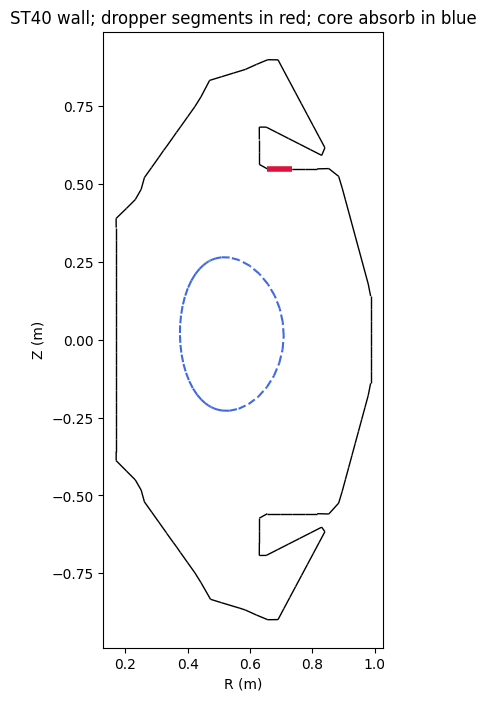

In [5]:
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection

%matplotlib inline

def read_surf(path):
    pts, lines, section = {}, [], None
    for s in Path(path).read_text().splitlines():
        s = s.strip()
        if s.lower() in ("points", "lines"): section = s.lower(); continue
        if section is None or not s or not s[0].isdigit(): continue
        p = s.split()
        if section == "points": pts[int(p[0])] = (float(p[2]), float(p[1]))  # (R, Z)
        elif len(p) == 3: lines.append(tuple(map(int, p)))
    return pts, lines

pts0, lines0 = read_surf(INP/"st40_wall_axi.surf")
ptsc, linesc = read_surf(INP/"st40_core.surf")

fig, ax = plt.subplots(figsize=(6, 8))
ax.add_collection(LineCollection([[pts0[a], pts0[b]] for _, a, b in lines0], colors="k", lw=1))
ax.add_collection(LineCollection([[pts0[a], pts0[b]] for i, a, b in lines0 if i in (40, 41)],
                                 colors="crimson", lw=4))
ax.add_collection(LineCollection([[ptsc[a], ptsc[b]] for _, a, b in linesc],
                                 colors="royalblue", lw=1.5, linestyle="--"))
ax.autoscale(); ax.set_aspect("equal")
ax.set_xlabel("R (m)"); ax.set_ylabel("Z (m)")
ax.set_title("ST40 wall; dropper segments in red; core absorb in blue")


### Wall cross-check: OpenEdge wall vs SOLPS structures

The OpenEdge wall (= EIRENE wall from `input.dat` 3b) vs the DivGeo limiter
template the mesh was built against (`11336_ELMAG...ogr`, mm; no `mesh.extra`
in this run) and the EIRENE mesh outer boundary. The mesh boundary is the edge
of the *plasma domain*, not a wall — SOLPS stops at the outer flux surface
except where the grid contacts the wall/targets. The `.ogr` differs from the
EIRENE wall only by two limiter tabs (top/bottom left) EIRENE drops.

DivGeo .ogr vs OpenEdge wall: mean 4.4 mm, max 83.1 mm at (R=0.356, Z=-0.797)


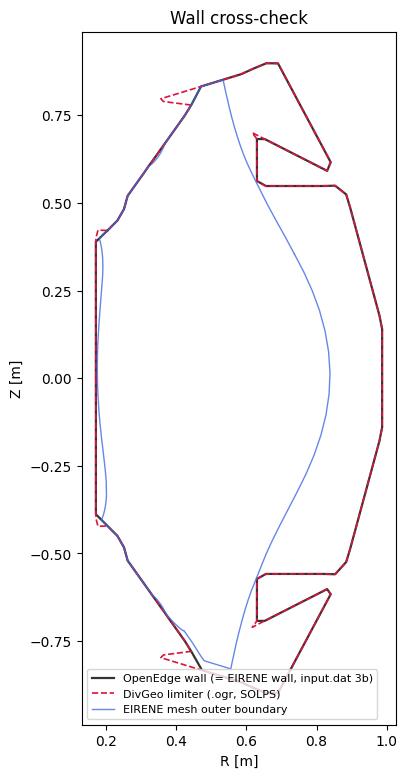

In [6]:
from collections import defaultdict

OGR = Path("/Users/42d/Downloads/13589/baserun/11336_ELMAG.BEST.LIMITER.LIMIT_PTS.ogr")
O = np.loadtxt(OGR) / 1000.0                      # mm -> m
O = np.vstack([O, O[0]])

with h5py.File(INP/"plasma_st40_solps.h5", "r") as f:
    vr, vz = f["mesh/vtx_r"][:], f["mesh/vtx_z"][:]
    tri = f["mesh/triangles"][:][f["mesh/cell_index"][:] >= 0]
cnt = defaultdict(int)
for a, b, c in tri:
    for e in ((a, b), (b, c), (c, a)): cnt[(min(e), max(e))] += 1
nbrs = defaultdict(list)
for a, b in (e for e, n in cnt.items() if n == 1):
    nbrs[a].append(b); nbrs[b].append(a)
unused = {e for e, n in cnt.items() if n == 1}
loops = []
while unused:
    a0, b0 = next(iter(unused)); lp = [a0, b0]; unused.discard((a0, b0))
    while True:
        p, c = lp[-2], lp[-1]
        nxt = [v for v in nbrs[c] if v != p and (min(c, v), max(c, v)) in unused]
        if not nxt: break
        lp.append(nxt[0]); unused.discard((min(c, nxt[0]), max(c, nxt[0])))
        if nxt[0] == lp[0]: break
    if lp[0] == lp[-1]: loops.append(lp[:-1])
outer = max(loops, key=len)
E = np.column_stack([vr[outer + [outer[0]]], vz[outer + [outer[0]]]])

W = surf_loop_rz(INP/"st40_wall_axi.surf")
SW = np.stack([W[:-1], W[1:]], axis=1)
def pt_seg(p, a, b):
    ab = b - a; t = np.clip(np.dot(p - a, ab) / np.dot(ab, ab), 0, 1)
    return np.linalg.norm(p - (a + t * ab))
dev = [min(pt_seg(p, a, b) for a, b in SW) for p in O[:-1]]
i = int(np.argmax(dev))
print(f"DivGeo .ogr vs OpenEdge wall: mean {1000*np.mean(dev):.1f} mm, "
      f"max {1000*max(dev):.1f} mm at (R={O[i,0]:.3f}, Z={O[i,1]:.3f})")

fig, ax = plt.subplots(figsize=(6.5, 9))
ax.plot(W[:, 0], W[:, 1], "-", color="0.2", lw=1.6, label="OpenEdge wall (= EIRENE wall, input.dat 3b)")
ax.plot(O[:, 0], O[:, 1], "--", color="crimson", lw=1.2, label="DivGeo limiter (.ogr, SOLPS)")
ax.plot(E[:, 0], E[:, 1], "-", color="royalblue", lw=1.0, alpha=0.8,
        label="EIRENE mesh outer boundary")
ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_title("Wall cross-check")
ax.legend(loc="lower left", fontsize=8)


## 2. SOLPS → `plasma_st40_solps.h5` + core-absorb surface

The core-absorb surface is the **inner boundary of the SOLPS mesh itself** (the
B2 grid's core cut), extracted from the triangulation — so particles are absorbed
exactly where the plasma data ends and no vacuum-floor shell is left in between.

## 3. Species and Li reaction chain (Li → Li⁺ → Li²⁺ → Li³⁺)

In [7]:
AMU = 1.66053906660e-27
R_GRAIN, RHO_LI, T_GRAIN = 5.0e-5, 534.0, 773.15
m = 4/3*math.pi*R_GRAIN**3*RHO_LI
with open(INP/"droplet.species", "w") as f:
    f.write("# Li powder grain (droplet macroparticle)\n")
    f.write("# ID Molwt(amu) Molmass(kg) RotDof RotRel VibDof VibRel VibTemp(K) specwt charge radius(m) temp(K)\n")
    f.write(f"droplet {m/AMU:.15e} {m:.15e} 0 0 0 0 0 1 0 {R_GRAIN:g} {T_GRAIN:g}\n")
with open(INP/"li.species", "w") as f:
    f.write("# atomic Li vapor + Li ions (charge states to 3+)\n")
    f.write("# ID Molwt(amu) Molmass(kg) RotDOF RotRel VibDOF VibRel VibTemp(K) speciesWt charge\n")
    for name, q in (("Li", 0), ("Li+", 1), ("Li2+", 2), ("Li3+", 3)):
        f.write(f"{name:5s}  6.94    1.15225e-26     0  0.0  0  0.0  0.0  1.0  {q}.0\n")
with open(INP/"li.reactions", "w") as f:
    f.write("# Li ionization/recombination chain to Li3+ (kinetic, ADAS scd/acd).\n")
    for lo, hi in (("Li", "Li+"), ("Li+", "Li2+"), ("Li2+", "Li3+")):
        f.write(f"{lo} --> {hi}\nI A 1.0 0.0 0.0 0.0 0.0\n\n")
        f.write(f"{hi} --> {lo}\nR A 1.0 0.0 0.0 0.0 0.0\n\n")
print(f"species + reactions written to input/ (grain r={R_GRAIN*1e6:g} um)")


species + reactions written to input/ (grain r=50 um)


## 4. Deck (`in.st40`)

In [8]:
DECK = r"""# =====================================================================
# ST40 (Tokamak Energy) — Li powder dropper, OpenEdge
# Grains fall from a top dropper, evaporate to Li vapor, ionise up to
# Li3+ and follow field lines through the SOLPS-13589 background.
# Axisymmetric mode (boundary o ao p): x = Z [m], y = R [m], ylo = axis.
# Surf files and dumps are in (Z, R).
# =====================================================================

# dt is set by the Li kinetics (the fastest species tracked): neutral flight
# ~3 mm/step and ion streaming ~1 cm per Boris sub-step (< 1 cell). Droplets
# are insensitive (drag is an exact exponential update; evaporation
# sub-steps internally), so one small global dt is both the accurate and
# the SPARTA-idiomatic choice — SPARTA has no per-species timestep.
variable    dt        equal 2.0e-6
variable    nsteps    equal 50000
variable    ndump     equal 500
variable    nemit     equal 200       # emit a grain batch every nemit steps
variable    npergroup equal 20        # grains per emit batch

shell       mkdir output

seed        12345
dimension   2
boundary    o ao p
global      gridcut 0.0 comm/sort no
global      fnum 1.0e14
timestep    ${dt}

create_box  -1.0 1.0  0.0 1.05  -0.05 0.05



create_grid 130 72 1
balance_grid rcb cell
global      weight cell radius        # annular (axi) cell volumes

# ---- species + mixtures ---------------------------------------------
species     input/droplet.species droplet
species     input/li.species      Li Li+ Li2+ Li3+
# mixtures are species lists only here: grain count/speed are explicit in
# droplet/emit, and evaporate emits vapor mass-conservingly at the grain
# temperature — mixture nrho/temp/vstream would be ignored.


mixture     droplet droplet frac 1.0
mixture     livapor Li      frac 1.0
mixture     allLi Li Li+ Li2+ Li3+

# ---- geometry --------------------------------------------------------
read_surf   input/st40_wall_axi.surf group wall particle check
read_surf   input/st40_core.surf group core     # core absorb (mesh inner boundary)

group dropper surf id <> 40 41       # ids printed by build_geometry.py

surf_collide vac  vanish
surf_modify  wall collide vac
surf_modify  core collide vac

# ---- frozen SOLPS background (plasma + B + psi embedded) -------------

fix pd background file input/plasma_st40_solps.h5 static yes



# NOTE: the WEST decks also add sheath physics to the pusher
# (compute nearest_surf/grid + `sheath boundary geom cgeom mD_amu 2.0`).
# That is OFF here: the per-grid cgeom arrays go stale when fix adapt
# refines the grid mid-run and the pusher then reads them -> bus error
# (known OpenEdge bug). Re-enable sheath only in runs without fix adapt.

# Li ion pusher (axi requires mode boris). Expect ONE
# "|q/m|*|B|*dt_sub is large" warning when the first Li+ appears: with
# subcycles 10 the gyro-ROTATION is deliberately unresolved (resolving it
# needs ~2000 subcycles). Boris keeps v_par and |v_perp| exact, so the
# error is bounded at the ~1 mm gyroradius (< cell); parallel streaming
# (~1 cm per sub-step) is what dt is sized for.



global      pusher plasma pd mode boris &
            subcycles 10 bad_dt_check yes bad_dt_limit 0.5

# ---- forces on Li ions: same physics as test_west_cases --------------
# Coulomb collisions (friction/slowing on the D background), anomalous
# cross-field diffusion, and ion+electron thermal-gradient forces.
variable    Dperp index 0.1
fix fcd     cross_field_diffusion 1 background pd D_perp ${Dperp}
fix fcoul   coulomb/background 1 background pd 2.0 1.0
fix fth     force/thermal 1 background pd ion_thermal yes elec_thermal yes

# ---- LPD chain: emit grains -> drag/gravity -> evaporate -> ionise ---
fix fdrop   grain/emit droplet dropper nevery ${nemit} n ${npergroup} &
            perspecies no normal no vmin 2.0 vmax 6.0 angle cosine

# gravity given as physical (gR, gZ, gphi)
fix fdrag   grain/drag   1 2.0 1 background pd gravity 0 -9.8 0 model epstein material Li
fix fcharge grain/charge 1 background pd ion_mass_amu 2.0 thermionic no mixture droplet material Li

# OML heating from local ne/Te/Ti (grains fly through the SOL volume,
# where the field-parallel target flux q_par is near zero)
fix fevap   grain/ablate 1 droplet background pd &
            heatflux/scale 1.0 rocket_eta 0.5 emit_into livapor &
            heating oml ion_mass_amu 2.0 material Li
            
            
fix fchem   volume/chem/adas 1 Li input/li.reactions output summary

# ---- diagnostics -----------------------------------------------------
# particles: type 1 = grain, 2 = Li, 3 = Li+, 4 = Li2+, 5 = Li3+ (x=Z, y=R)
dump dpart particle all ${ndump} output/state id type x y z vx vy vz radius temp

# total-Li density n_Li [m^-3], time-averaged, dumped at steps 1000/2000
fix     fpw particle/weight
compute cli grid/weighted all allLi nrho_w

fix     fli ave/grid all 100 100 10000 c_cli[1] ave one
dump    dgrid grid all 10000 output/li_dens id xc yc f_fli

# adaptive refinement around Li (vapor + ions): value style keys on n_Li,
# so cells holding only grains are untouched (must come after ave/grid)
fix     fadapt adapt 2000 all refine value c_cli[1] 5.0e15 1.0e14 maxlevel 3
# NOTE: no `fix balance` here — re-owning cells after fix adapt refinement
# leaves stale neighbor/ghost links (known OpenEdge bug: particles crossing
# those faces dereference garbage cell ids -> intermittent MPI bus errors).

stats       ${ndump}
stats_style step cpu np
run         ${nsteps}
"""
(ROOT/"in.st40").write_text(DECK)
print("wrote in.st40")


wrote in.st40


## 5. Run

In [9]:
env = dict(os.environ, OPENEDGE_ROOT=str(OPENEDGE_ROOT))
import shutil
mpirun = shutil.which("mpirun") or "/opt/homebrew/bin/mpirun"
run_cmd([mpirun, "-np", "4", OPENEDGE_BIN, "-in", "in.st40"], cwd=ROOT, env=env)


+ /opt/homebrew/bin/mpirun -np 4 /Users/42d/build_oe/src/spa_mac_mpi -in in.st40


SPARTA-OPENDGE (20 Jan 2025)
Running on 4 MPI task(s)
Created orthogonal box = (-1 0 -0.05) to (1 1.05 0.05)
Created 9360 child grid cells
  CPU time = 0.001715 secs
  create/ghost percent = 10.4373 89.5627
Balance grid migrated 7020 cells
  CPU time = 0.013629 secs
  reassign/sort/migrate/ghost percent = 62.4037 0.0440238 35.9968 1.55551
Reading surface file ...
  139 lines
  -0.898743 0.898743 xlo xhi
  0.170352 0.987212 ylo yhi
  0 0 zlo zhi
  0.0045069 min line length
  426 0 = cells overlapping surfs, overlap cells with unmarked corner pts


  4474 4460 426 = cells outside/inside/overlapping surfs
  426 = surf cells with 1,2,etc splits
  3.7417391908984 3.7417391908984 = cell-wise and global flow volume
  CPU time = 0.001109 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 9.01713 22.8133 2.25428 51.578 14.3372 149.955 0.0901713
  surf2grid time = 0.000572 secs
  map/comm1/comm2/comm3/comm4/split percent = 24.1259 2.27273 15.5594 1.92308 16.2587 32.5175
Reading surface file ...
  50 lines
  -0.227915 0.264656 xlo xhi
  0.375145 0.708279 ylo yhi
  0 0 zlo zhi
  0.00241117 min line length
  536 0 = cells overlapping surfs, overlap cells with unmarked corner pts
  3846 4978 536 = cells outside/inside/overlapping surfs
  536 = surf cells with 1,2,etc splits
  3.30977615435172 3.30977615435172 = cell-wise and global flow volume
  CPU time = 0.000686 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 10.0583 4.51895 10.4956 45.3353 29.5918 11.0787 0
  surf2grid time = 0.000311 secs
  map/comm1/comm2/c

Reading ADAS data for li (Z=3) from /Users/42d/OpenEdge/database/processes.h5 (/volume/rates/)
  boris: bfield_compute 'pd' bound to fix background (has_bfield=0, mesh_tri_b=0)
[background] Reading input/plasma_st40_solps.h5
[background] loaded embedded equilibrium (jm=65 km=65 psi_axis=-1.800809e-02 psib=3.403973e-03)
[background] /wall_flux/ loaded: N=166 nspec=7
[background] Loaded: mesh 7207 tri / 3690 cell / 3806 vtx, 7 ion species, bfield=grid, equ=yes, gen=1
[volume/chem/adas] ionization    : 3 active, 0 skipped (of 3)
[volume/chem/adas] recombination : 3 active, 0 skipped (of 3)
[volume/chem/adas] output summary  (6 cols)  ADAS tables: SCD ACD CCD - - IP
Memory usage per proc in Mbytes:
  particles (ave,min,max) = 0 0 0
  grid      (ave,min,max) = 1.51379 1.51379 1.51379
  surf      (ave,min,max) = 0.0194664 0.0194664 0.0194664
  total     (ave,min,max) = 1.60467 1.60467 1.60467
Step CPU Np 
       0            0        0 
     500     0.007308       37 
    1000     0.015994  

    3500      0.12985      339 


...

   48000    65.846286     3864 


   48500    67.357217     3878 


   49000    68.850717     3903 


   49500    70.325136     3921 


   50000    71.847202     3954 
Chem/ADAS reaction tallies:
  id fchem Z=3 #-of-reactions 6
    reaction all: 10755
    ioniz: 10754
    recomb: 1
    CX: 0
    dissoc: 0
Loop time of 71.8472 on 4 procs for 50000 steps with 3954 particles

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Move    | 0.005923   | 2.5935     | 10.322     | 277.1 |  3.61
Coll    | 0          | 0          | 0          |   0.0 |  0.00
Sort    | 0          | 0          | 0          |   0.0 |  0.00
Comm    | 0.17344    | 0.24138    | 0.39024    |  17.7 |  0.34
Modify  | 0.22654    | 15.19      | 59.834     | 661.3 | 21.14
Output  | 0.22727    | 0.26164    | 0.27353    |   3.9 |  0.36
Pcache  | 0.002216   | 0.2553     | 1.0127     |  86.5 |  0.36
Other   |            | 53.31      |            |       | 74.19

Particle moves    = 113247249 (113M)
Cells touched     = 114100609 (114M)
Particle comms    = 12165 

## 6. Camera-style picture and total-Li density map

wrote /Users/42d/OpenEdge/examples/test_st40_li_dropper/st40_lpd_chain.png | last step 50000 | {'grain': 3916, 'Li': 23, 'Li$^+$': 13, 'Li$^{2+}$': 2, 'Li$^{3+}$': 0}


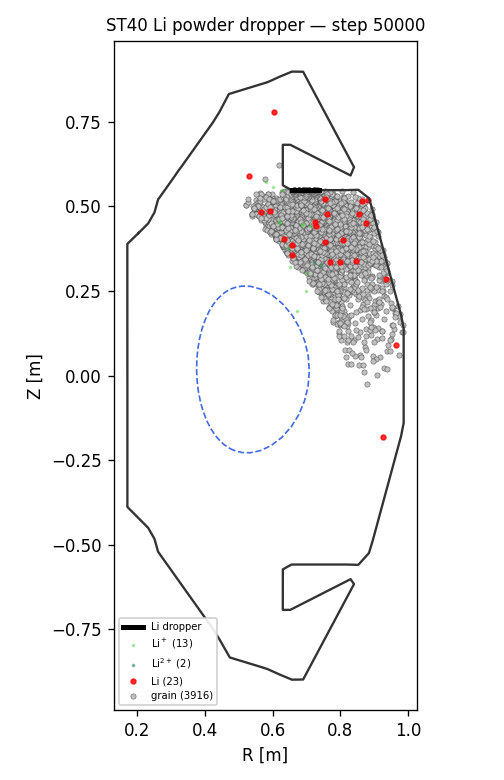

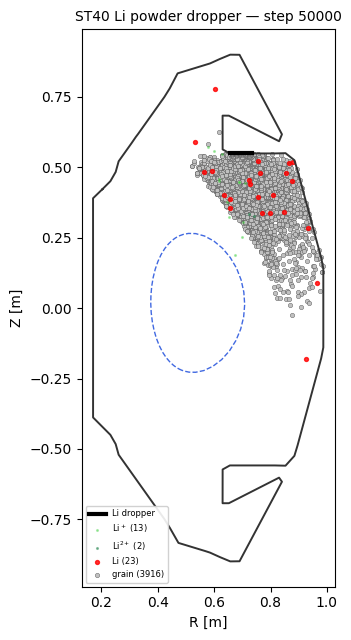

In [10]:
plot_lpd.main()
from IPython.display import Image
Image(str(ROOT/"st40_lpd_chain.png"))


wrote /Users/42d/OpenEdge/examples/test_st40_li_dropper/st40_li_density.png | step 50000 | n_Li max = 2.728e+14 m^-3


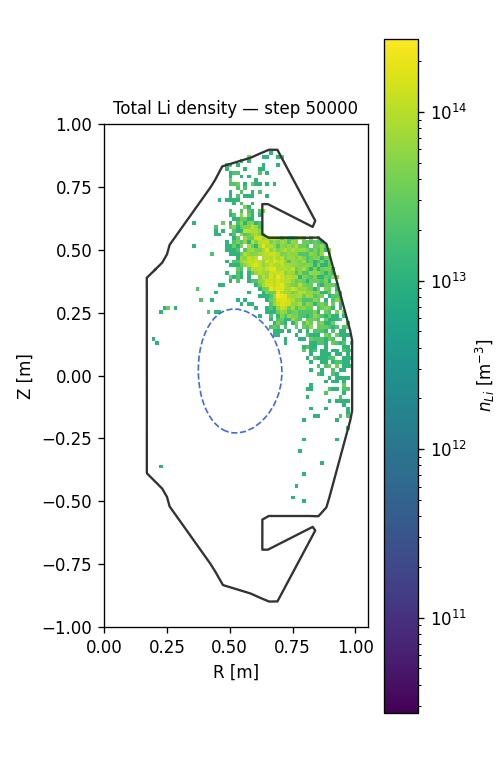

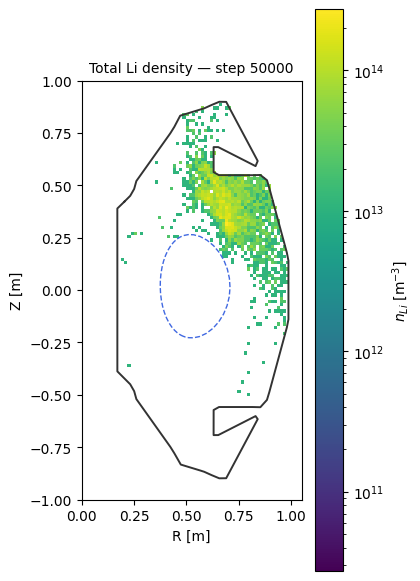

In [11]:
plot_lpd.plot_density()
Image(str(ROOT/"st40_li_density.png"))
